The main model training script, left with the setup for the best performing one - ConvNeXt

In [1]:
import os
import time
import copy
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# --- Configuration ---
DATA_DIR = Path("../data/labeled_dataset_final") 
OUTPUT_DIR = Path("runs/classifier_convnext")
NUM_CLASSES = 8
BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# GDDKiA Class Mapping (Ensure folders match these alphabetic orders)
CLASS_NAMES = ['a_bikes', 'b_moto', 'c_pass', 'd_light_comm', 
               'e_heavy_rigid', 'f_articulated', 'g_bus', 'h_agri']

In [2]:
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
def get_transforms():
    norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    
    return {
        'train': transforms.Compose([
            transforms.Resize((236, 236)),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                            brightness=0.3, 
                            contrast=0.3,   
                            saturation=0.2, 
                            hue=0.05
                        ),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
            ], p=0.1), 
            transforms.ToTensor(),
            norm
        ]),
        'val': transforms.Compose([
            transforms.Resize((236, 236)),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            norm
        ])
    }

def create_weighted_sampler(dataset):
    # Calculate weights to balance the class imbalance
    targets = torch.tensor(dataset.targets)
    class_counts = torch.bincount(targets)
    class_weights = 1.0 / class_counts.float()
    
    # Assign a weight to every sample corresponding to its class
    sample_weights = class_weights[targets]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def train_model():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Data Setup
    transforms_dict = get_transforms()
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=transforms_dict['train'])
    assert len(full_dataset.classes) == NUM_CLASSES, \
        f"Expected {NUM_CLASSES} classes, but ImageFolder found {len(full_dataset.classes)}: {full_dataset.classes}"
    
    # Split Train/Val (80/20)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    val_dataset.dataset.transform = transforms_dict['val']
    
    # Create Sampler for Training ONLY
    train_targets = [full_dataset.targets[i] for i in train_dataset.indices]
    
    # Calculate weights manually for the subset
    class_counts = np.bincount(train_targets)
    class_weights = 1. / class_counts
    sample_weights = [class_weights[t] for t in train_targets]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4),
        'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    }

    print(f"Classes: {full_dataset.classes}")
    print(f"Training on {len(train_dataset)} images, Validating on {len(val_dataset)}")

    # 2. Model Setup, adjust per model
    print("Loading ConvNeXt-Base...")
    model = models.convnext_base(weights='IMAGENET1K_V1')
    
    for param in model.features[0:6].parameters():
        param.requires_grad = False
        
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
    
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # 3. Training Loop
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    history = []

    for epoch in range(NUM_EPOCHS):
        print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}')

            history.append({
                'epoch': epoch + 1,
                'phase': phase,
                'loss': epoch_loss,
                'accuracy': epoch_acc,
                'f1_macro': epoch_f1
            })

            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pth")
                print("--> New Best Model Saved!")

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Macro-F1: {best_f1:.4f}')

    model.load_state_dict(best_model_wts)
    
    # Save History to CSV
    pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_log.csv", index=False)
    
    # Generate Confusion Matrix on Validation Set
    model.eval()
    y_true = []
    y_pred = []
    with torch.inference_mode():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix (Best F1: {best_f1:.2f})')
    plt.savefig(OUTPUT_DIR / "confusion_matrix.png")
    print(f"Confusion matrix saved to {OUTPUT_DIR}")
    
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    print("\nFinal Classification Report:\n")
    print(report)
    with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
        f.write(report)

Classes: ['a_bikes', 'b_moto', 'c_pass', 'd_light_comm', 'e_heavy_rigid', 'f_articulated', 'g_bus', 'h_agri']
Training on 10584 images, Validating on 2647
Loading ConvNeXt-Base...

Epoch 1/10
----------
train Loss: 0.8573 Acc: 0.8711 Macro-F1: 0.8697
val Loss: 0.6641 Acc: 0.9146 Macro-F1: 0.8467
--> New Best Model Saved!

Epoch 2/10
----------
train Loss: 0.6059 Acc: 0.9492 Macro-F1: 0.9487
val Loss: 0.6443 Acc: 0.9320 Macro-F1: 0.8950
--> New Best Model Saved!

Epoch 3/10
----------
train Loss: 0.5697 Acc: 0.9623 Macro-F1: 0.9623
val Loss: 0.6200 Acc: 0.9373 Macro-F1: 0.8986
--> New Best Model Saved!

Epoch 4/10
----------
train Loss: 0.5415 Acc: 0.9769 Macro-F1: 0.9769
val Loss: 0.6267 Acc: 0.9335 Macro-F1: 0.8930

Epoch 5/10
----------
train Loss: 0.5333 Acc: 0.9779 Macro-F1: 0.9778
val Loss: 0.6084 Acc: 0.9418 Macro-F1: 0.9046
--> New Best Model Saved!

Epoch 6/10
----------
train Loss: 0.5219 Acc: 0.9835 Macro-F1: 0.9834
val Loss: 0.6055 Acc: 0.9430 Macro-F1: 0.8995

Epoch 7/10
--

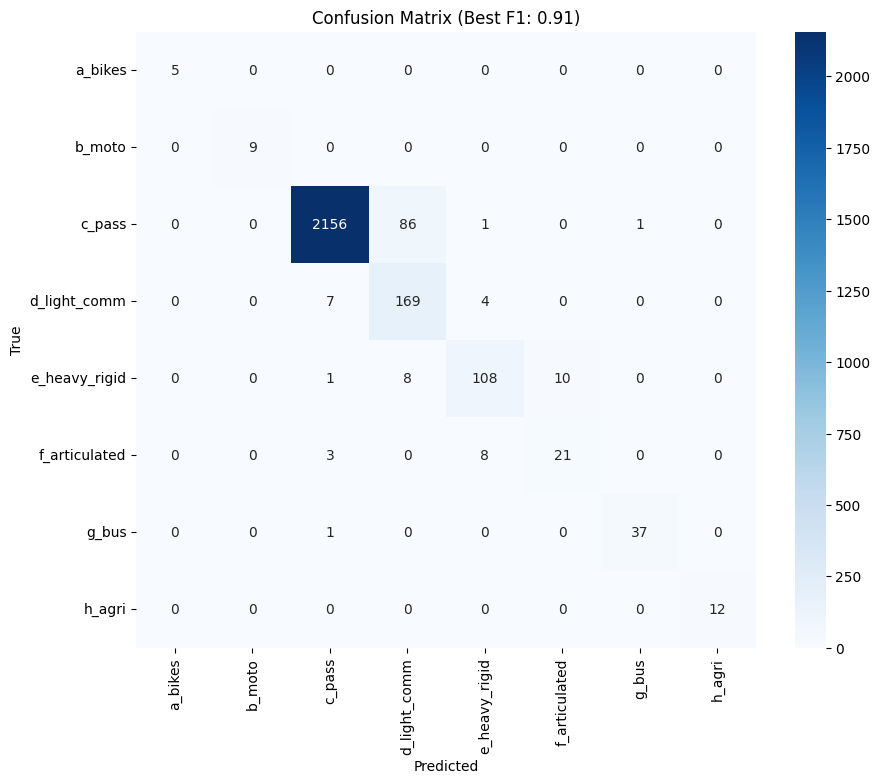

In [4]:
if __name__ == "__main__":
    train_model()

Display 8x8 matrix of class pred/true images

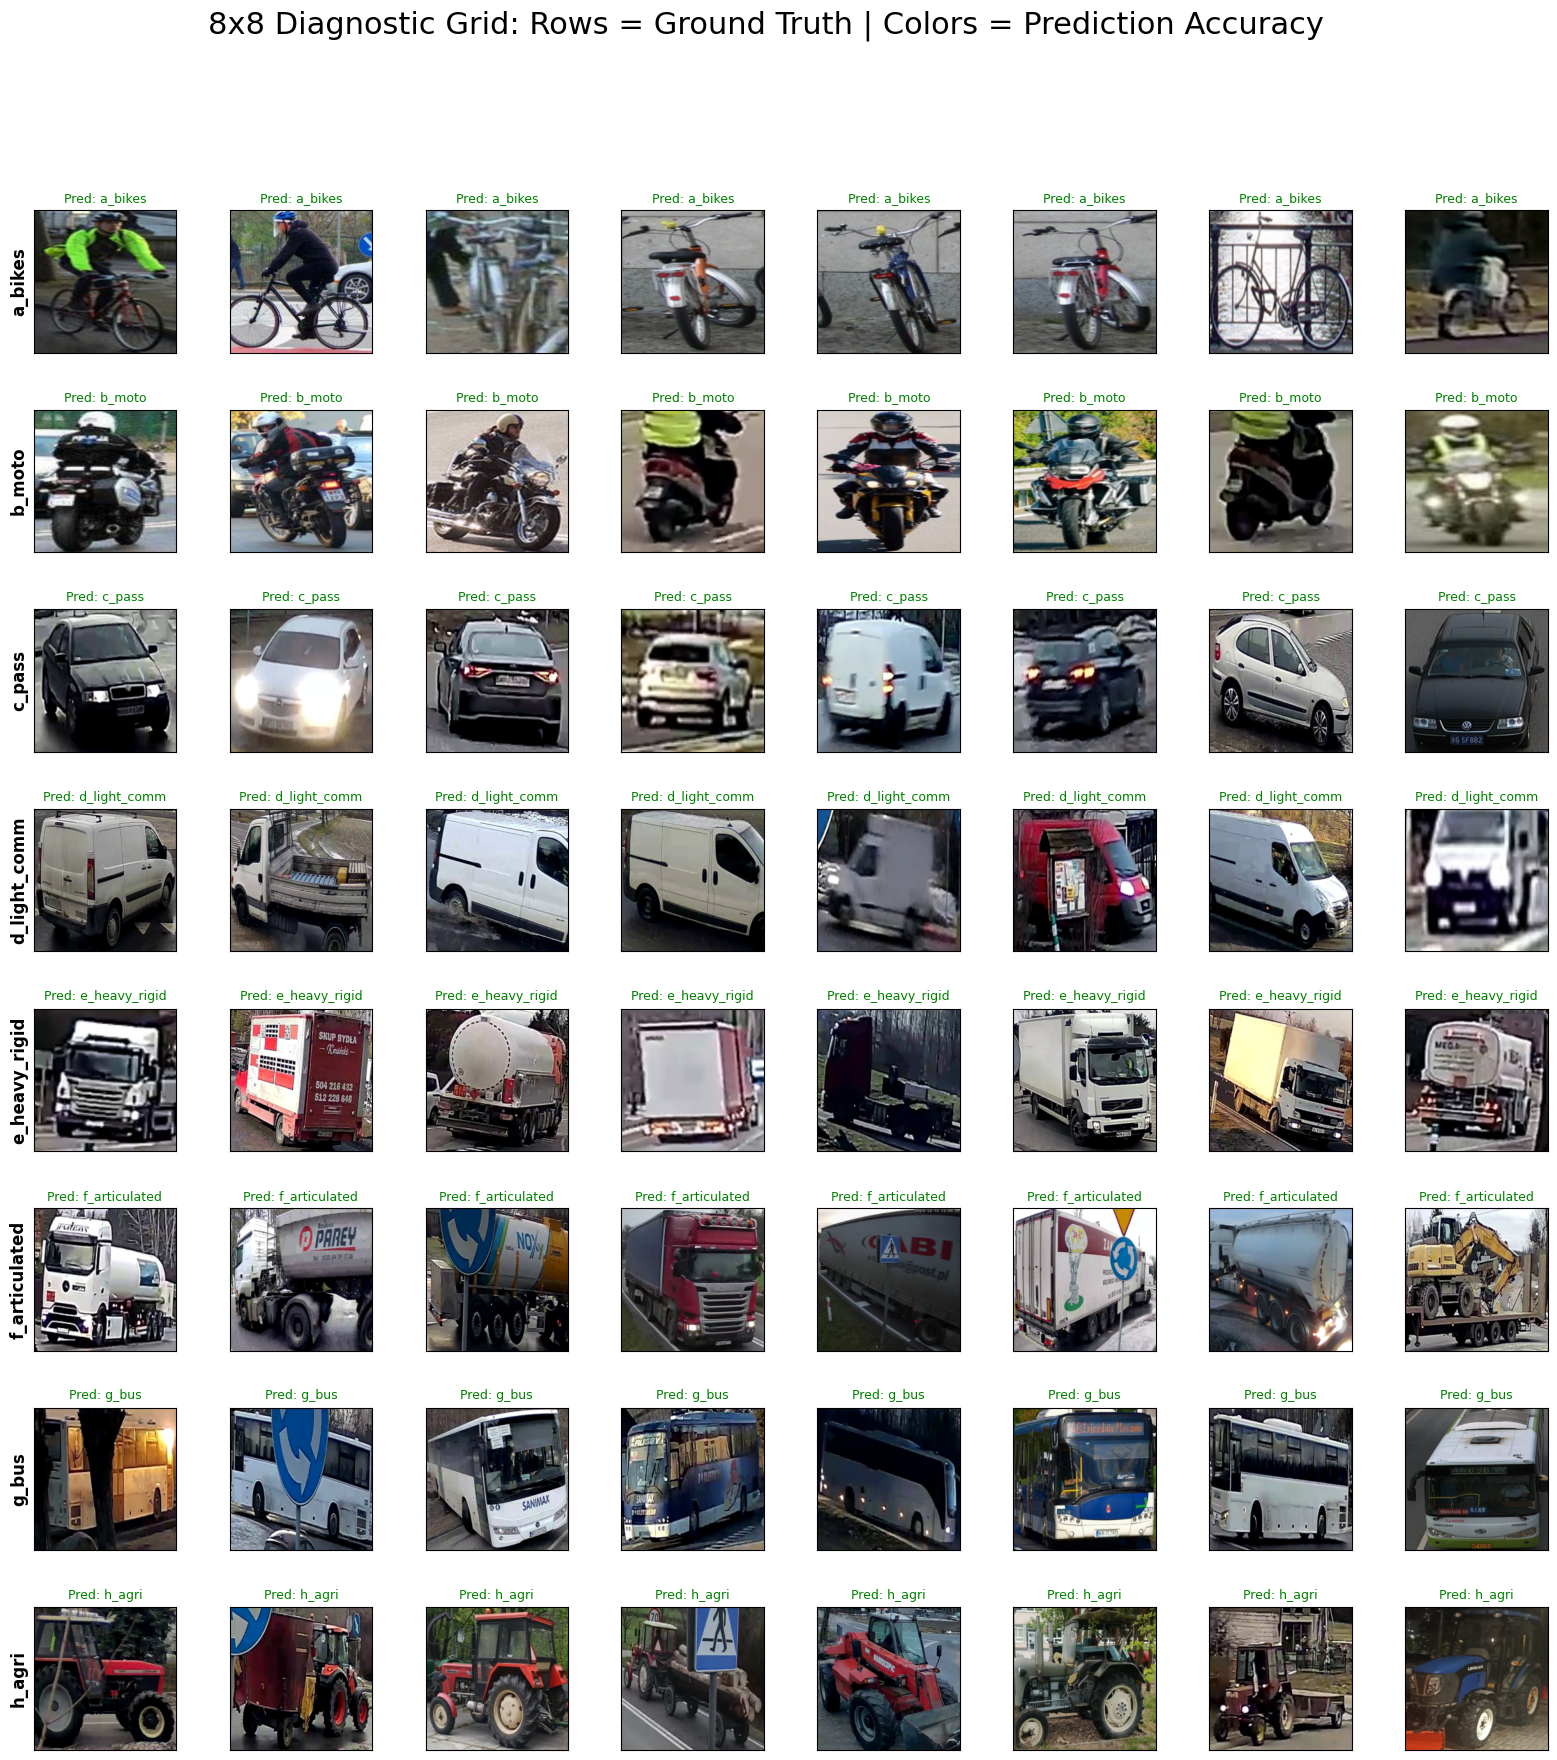

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path

DATA_DIR = Path("../data/labeled_dataset_final")
MODEL_PATH = Path("runs/classifier_convnext/best_model.pth")
CLASS_NAMES = ['a_bikes', 'b_moto', 'c_pass', 'd_light_comm', 
               'e_heavy_rigid', 'f_articulated', 'g_bus', 'h_agri']
NUM_CLASSES = 8
IMAGES_PER_CLASS = 8  
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def visualize_class_grid():
    model = models.convnext_base(weights=None)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

    class_indices = {i: [] for i in range(NUM_CLASSES)}
    for idx, (_, label) in enumerate(dataset.imgs):
        class_indices[label].append(idx)


    fig, axes = plt.subplots(NUM_CLASSES, IMAGES_PER_CLASS, figsize=(20, 20))
    plt.subplots_adjust(hspace=0.4, wspace=0.1)

    for row, class_name in enumerate(CLASS_NAMES):
        selected_indices = random.sample(class_indices[row], k=min(IMAGES_PER_CLASS, len(class_indices[row])))
        
        for col, idx in enumerate(selected_indices):
            img_tensor, true_label_idx = dataset[idx]
            
            inputs = img_tensor.unsqueeze(0).to(DEVICE)
            with torch.inference_mode():
                outputs = model(inputs)
                _, pred_idx = torch.max(outputs, 1)
            
            pred_name = CLASS_NAMES[pred_idx.item()]
            true_name = CLASS_NAMES[true_label_idx]
            
            img = img_tensor.cpu().numpy().transpose((1, 2, 0))
            img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)

            ax = axes[row, col]
            color = 'green' if pred_name == true_name else 'red'
            ax.imshow(img)
            
            if col == 0:
                ax.set_ylabel(true_name, fontsize=12, fontweight='bold')
            
            ax.set_title(f"Pred: {pred_name}", color=color, fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle('8x8 Diagnostic Grid: Rows = Ground Truth | Colors = Prediction Accuracy', fontsize=22)
    plt.show()

if __name__ == "__main__":
    visualize_class_grid()